In [1]:
import copy
import os
import random
import shutil
import zipfile
from math import atan2, cos, sin, sqrt, pi, log
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image
from numpy import linalg as LA
from torch import optim, nn
from torch.utils.data import DataLoader, random_split
from torch.utils.data.dataset import Dataset
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import rioxarray
import numpy as np
from rasterio.enums import Resampling


In [2]:
current_dir = Path.cwd()
data_dir = current_dir.parent / "data"

copernicus_data = []
for file in (data_dir / "copernicus").glob("*.tif"):
    with rioxarray.open_rasterio(file) as data:
        copernicus_data.append(data.squeeze().drop_vars("band").load())

dataforsyningen_data = []
for file in (data_dir / "dataforsyningen").glob("*.tif"):
    with rioxarray.open_rasterio(file) as data:
        dataforsyningen_data.append(data.squeeze().drop_vars("band").load())

In [63]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)
    

class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)
        #print(f"DownSample: down shape: {down.shape}, pool shape: {p.shape}")
        return down, p
    
class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1)
        #print(f"UpSample: x shape: {x.shape}")
        return self.conv(x)
    
class UpSample_last(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=3, stride=3)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1)
        return self.conv(x)

In [64]:
class UNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
        self.down_convolution_4 = DownSample(256, 512)

        self.bottle_neck = DoubleConv(512, 1024)

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)
        self.up_convolution_5 = UpSample(64, 32)
        self.up_convolution_6 = UpSample(32,16)
        
        self.last_up_convolution = UpSample_last(64, 32)
        self.first_up_convolution_1 = nn.ConvTranspose2d(in_channels, 32, kernel_size=3, stride=3)

        self.out = nn.Conv2d(in_channels=32, out_channels=num_classes, kernel_size=1)

    def forward(self, x):

        first_1 = self.first_up_convolution_1(x)

        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        up_1 = self.up_convolution_1(b, down_4)
        up_2 = self.up_convolution_2(up_1, down_3)
        up_3 = self.up_convolution_3(up_2, down_2)
        up_4 = self.up_convolution_4(up_3, down_1)
        up_5 = self.last_up_convolution(up_4,first_1)

        out = self.out(up_5)
        return out

torch.Size([1, 512, 256])
torch.Size([1, 1, 1536, 768])


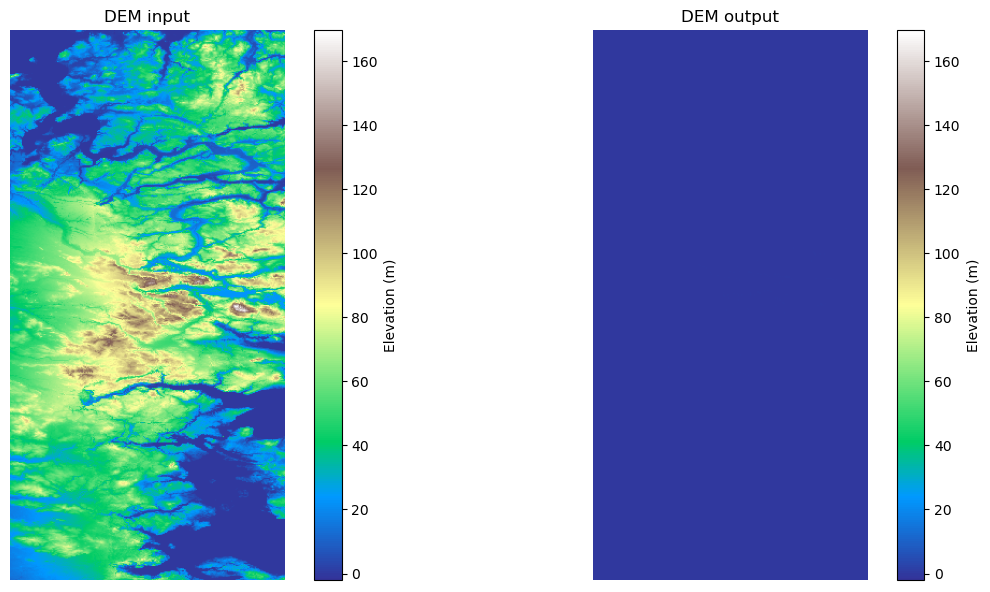

In [71]:
transform = transforms.Compose([
            transforms.ToTensor()])

tensor = transform(Image.open("dem_tile.tif"))
print(tensor.shape)

model = UNet(1,1)
output = model(tensor.unsqueeze(0))  # Add batch dimension
print(output.size())
# You should get torch.Size([1, 10, 512, 512]) as a result ..not!

DEM_output = output.detach().cpu().numpy().squeeze()
DEM_input = tensor.detach().cpu().numpy().squeeze()

# Optional: shared color range for fair visual comparison
vmin = min(DEM_input.min(), DEM_output.min())
vmax = max(DEM_input.max(), DEM_output.max())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(DEM_input, cmap="terrain", vmin=vmin, vmax=vmax)
axes[0].set_title("DEM input")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Elevation (m)")

im1 = axes[1].imshow(DEM_output, cmap="terrain", vmin=vmin, vmax=vmax)
axes[1].set_title("DEM output")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Elevation (m)")

plt.tight_layout()
plt.show()

In [66]:
print("Input DEM - min:", DEM_input.min(), "max:", DEM_input.max()
      , "mean:", DEM_input.mean(), "std:", DEM_input.std())
print("Output DEM - min:", DEM_output.min(), "max:", DEM_output.max()
      , "mean:", DEM_output.mean(), "std:", DEM_output.std())

Input DEM - min: -2.0098116 max: 169.58475 mean: 41.875824 std: 28.514538
Output DEM - min: -0.6607744 max: 0.15145344 mean: -0.051876735 std: 0.07677305


In [ ]:
def diff_in_height_coefficient(prediction, target, epsilon=1e-07):
    prediction_copy = prediction.clone()

    difference = torch.sum(torch.abs(prediction_copy - target))
    
    return difference

In [ ]:
LEARNING_RATE = 3e-4
BATCH_SIZE = 8
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

device = "cuda" if torch.cuda.is_available() else "cpu"
num_workers = torch.cuda.device_count() * 4 if device == "cuda" else 0
pin_memory = device == "cuda"

train_dataloader = DataLoader(
    dataset=train_dataset,
    num_workers=num_workers,
    pin_memory=pin_memory,
    batch_size=BATCH_SIZE,
    shuffle=True,
    )
val_dataloader = DataLoader(
    dataset=val_dataset,
    num_workers=num_workers,
    pin_memory=pin_memory,
    batch_size=BATCH_SIZE,
    shuffle=True,
    )

test_dataloader = DataLoader(
    dataset=test_dataset,
    num_workers=num_workers,
    pin_memory=pin_memory,
    batch_size=BATCH_SIZE,
    shuffle=True,
    )

model = UNet(in_channels=3, num_classes=1).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()


In [ ]:

EPOCHS = 10

train_losses = []
train_dcs = []
val_losses = []
val_dcs = []

for epoch in tqdm(range(EPOCHS)):
    model.train()
    train_running_loss = 0
    train_running_dc = 0
    
    for idx, img_mask in enumerate(tqdm(train_dataloader, position=0, leave=True)):
        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)
        
        y_pred = model(img)
        optimizer.zero_grad()
        
        dc = diff_in_height_coefficient(y_pred, mask)
        loss = criterion(y_pred, mask)
        
        train_running_loss += loss.item()
        train_running_dc += dc.item()

        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / (idx + 1)
    train_dc = train_running_dc / (idx + 1)
    
    train_losses.append(train_loss)
    train_dcs.append(train_dc)

    model.eval()
    val_running_loss = 0
    val_running_dc = 0
    
    with torch.no_grad():
        for idx, img_mask in enumerate(tqdm(val_dataloader, position=0, leave=True)):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].float().to(device)

            y_pred = model(img)
            loss = criterion(y_pred, mask)
            dc = diff_in_height_coefficient(y_pred, mask)
            
            val_running_loss += loss.item()
            val_running_dc += dc.item()

        val_loss = val_running_loss / (idx + 1)
        val_dc = val_running_dc / (idx + 1)
    
    val_losses.append(val_loss)
    val_dcs.append(val_dc)

    print("-" * 30)
    print(f"Training Loss EPOCH {epoch + 1}: {train_loss:.4f}")
    print(f"Training Difference EPOCH {epoch + 1}: {train_dc:.4f}")
    print("\n")
    print(f"Validation Loss EPOCH {epoch + 1}: {val_loss:.4f}")
    print(f"Validation Difference EPOCH {epoch + 1}: {val_dc:.4f}")
    print("-" * 30)

# Saving the model
torch.save(model.state_dict(), 'my_checkpoint.pth')